# Startup Success Prediction
## Part 1 — Supervised Learning

This notebook builds a complete supervised learning pipeline to predict startup outcomes
(**IPO**, **Acquisition**, **Failure**) from 10 features describing funding, team, market
and founder profile.

### Dataset
| Property | Value |
|---|---|
| Rows | 100 000 |
| Features | 10 (7 numerical, 3 categorical) |
| Target | `outcome` — 3 classes |
| Missing values | None |

### Notebook structure
1. Exploratory Data Analysis (EDA)
2. Preprocessing — `Pipeline` + `ColumnTransformer`
3. Hyperparameter Tuning — `GridSearchCV` for each model
4. Model Comparison — compare all tuned models
5. Final Evaluation — confusion matrix, ROC curves, feature importances


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler, OrdinalEncoder, FunctionTransformer, label_binarize
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 6)
print('All libraries imported successfully.')


All libraries imported successfully.


## Step 1 — Exploratory Data Analysis (EDA)

Before building any model we explore the dataset to understand feature distributions,
class balance, correlations, and how categorical features relate to the outcome.

This step is inspired by **TD04** (multi-class analysis) and **TD03** (categorical feature
exploration).


In [2]:
df = pd.read_csv('data/startup_success_dataset.csv')

print(f'Dataset shape : {df.shape}')
print()
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Outcome classes :', sorted(df['outcome'].unique()))
print('Investor types  :', sorted(df['investor_type'].unique()))
print('Sectors         :', sorted(df['sector'].unique()))
print('Founder profiles:', sorted(df['founder_background'].unique()))

df.head(5)


Dataset shape : (100000, 11)

Data types:
funding_rounds                int64
founder_experience_years      int64
team_size                     int64
market_size_billion         float64
product_traction_users        int64
burn_rate_million           float64
revenue_million             float64
investor_type                   str
sector                          str
founder_background              str
outcome                         str
dtype: object

Missing values:
funding_rounds              0
founder_experience_years    0
team_size                   0
market_size_billion         0
product_traction_users      0
burn_rate_million           0
revenue_million             0
investor_type               0
sector                      0
founder_background          0
outcome                     0
dtype: int64

Outcome classes : ['Acquisition', 'Failure', 'IPO']
Investor types  : ['angel', 'none', 'tier1_vc', 'tier2_vc']
Sectors         : ['AI', 'Climate', 'Crypto', 'Ecommerce', 'Fintech', 'Heal

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


In [3]:
print('=== Descriptive Statistics — Numerical Features ===')
df.describe().round(3)


=== Descriptive Statistics — Numerical Features ===


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,2.002,12.024,150.732,33.204,285422.833,16.776,782819.144
std,1.415,7.208,86.273,43.035,159323.885,15.711,608506.911
min,0.000,0.000,2.000,0.289,668.000,0.280,1344.810
25%,1.000,6.000,76.000,10.197,161194.750,7.088,315486.093
50%,2.000,12.000,151.000,20.158,264989.500,12.169,621362.389
75%,3.000,18.000,226.000,39.532,389214.000,20.954,1098920.637
max,8.000,24.000,299.000,1072.434,915203.000,357.491,4168442.503


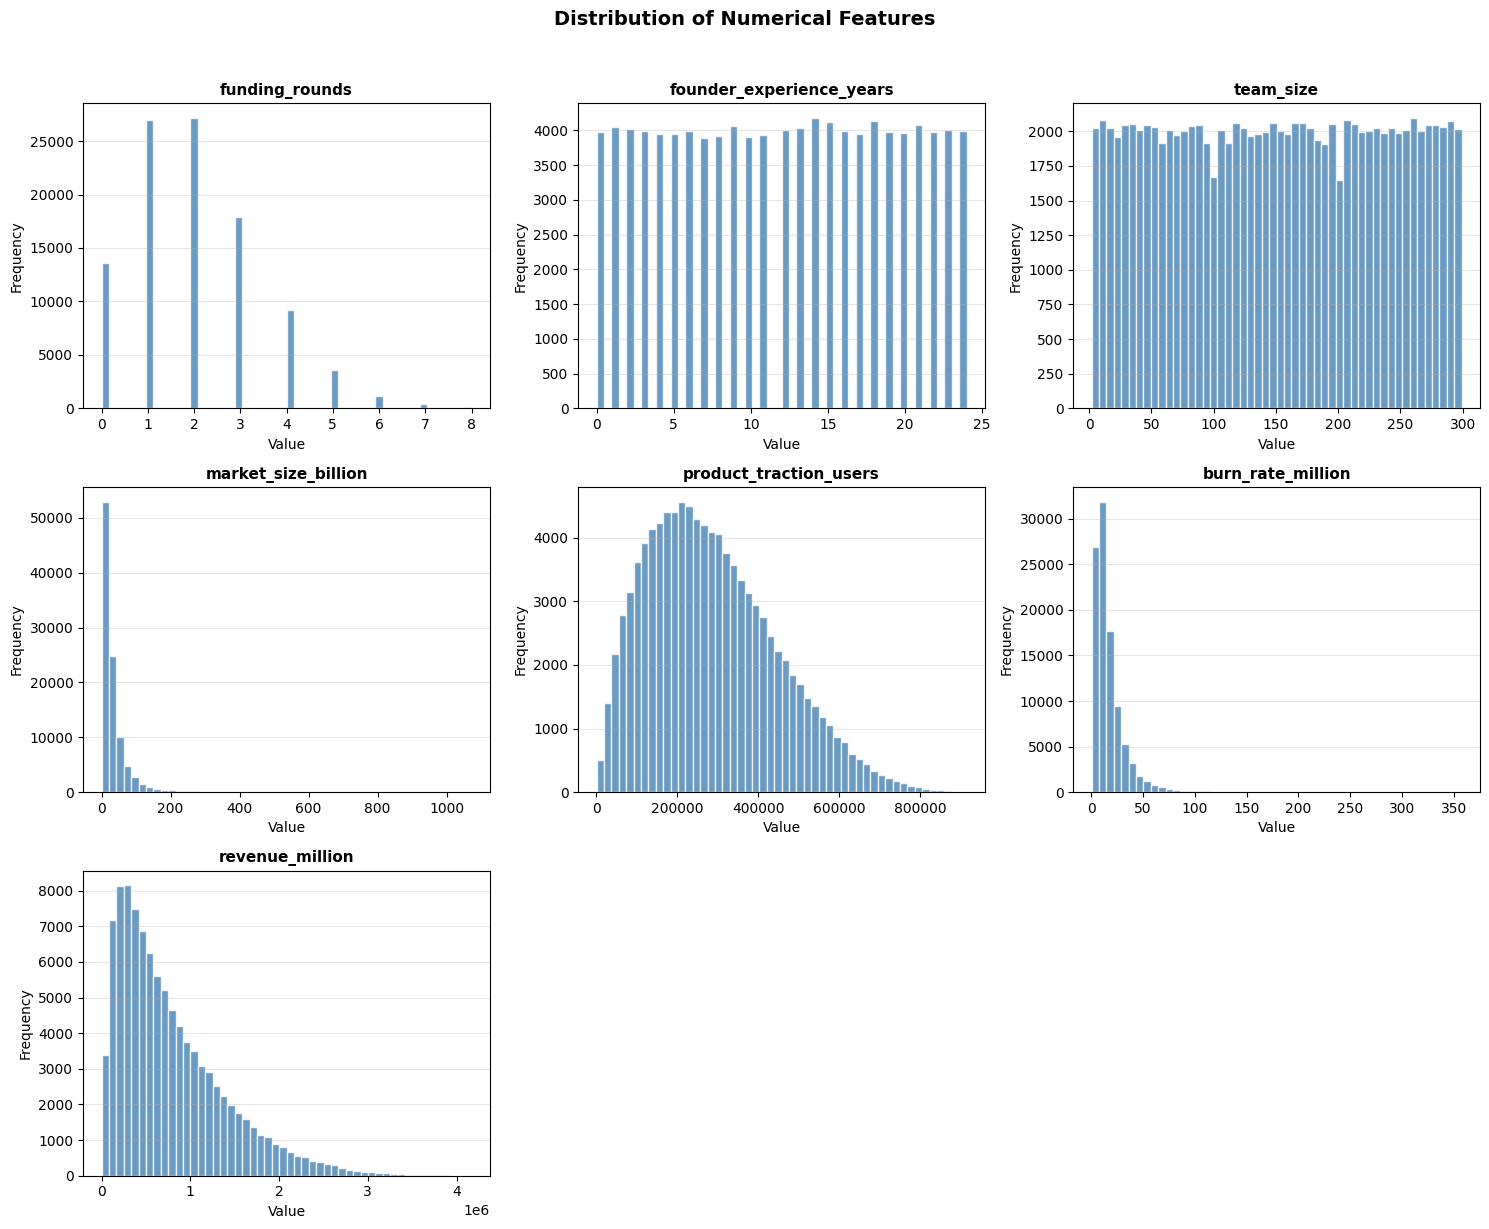

In [4]:
numerical_features = [
    'funding_rounds', 'founder_experience_years', 'team_size',
    'market_size_billion', 'product_traction_users',
    'burn_rate_million', 'revenue_million'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)

for j in range(len(numerical_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


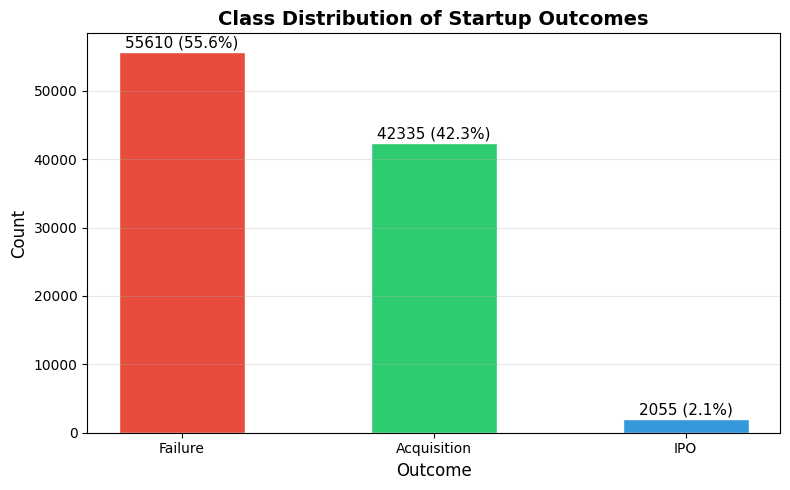

In [5]:
outcome_counts = df['outcome'].value_counts()
bar_colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(outcome_counts.index, outcome_counts.values,
              color=bar_colors, edgecolor='white', width=0.5)

for bar, count in zip(bars, outcome_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 200,
            f'{count} ({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Class Distribution of Startup Outcomes', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


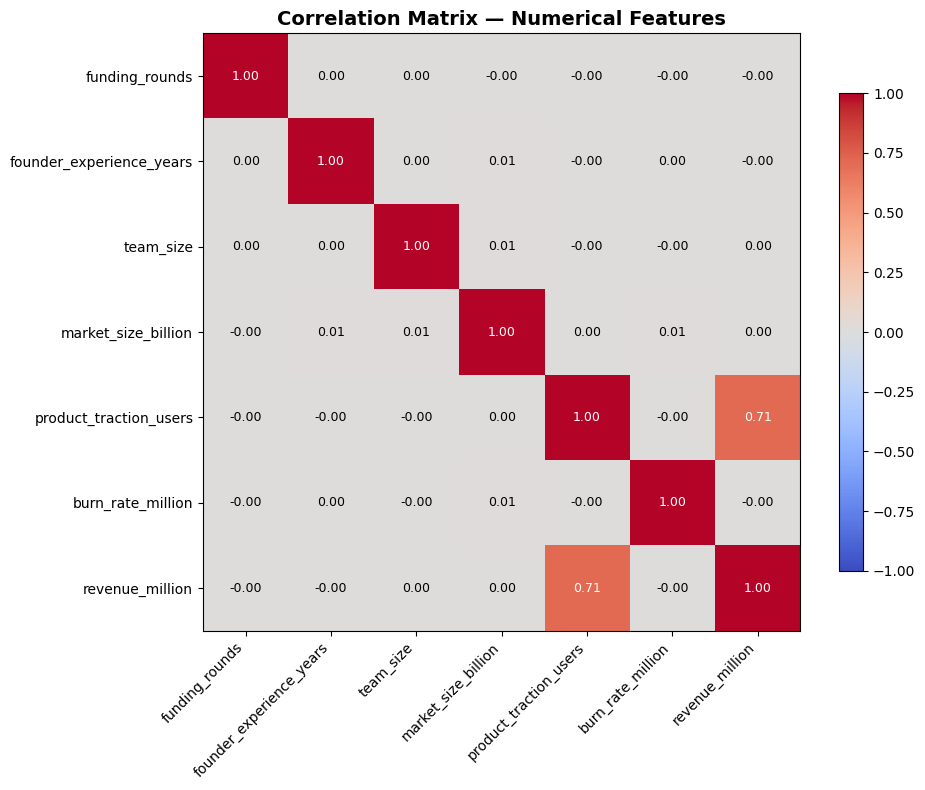

In [6]:
corr = df[numerical_features].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(numerical_features)))
ax.set_yticks(range(len(numerical_features)))
ax.set_xticklabels(numerical_features, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(numerical_features, fontsize=10)

for i in range(len(numerical_features)):
    for j in range(len(numerical_features)):
        val = corr.values[i, j]
        txt_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=txt_color)

ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


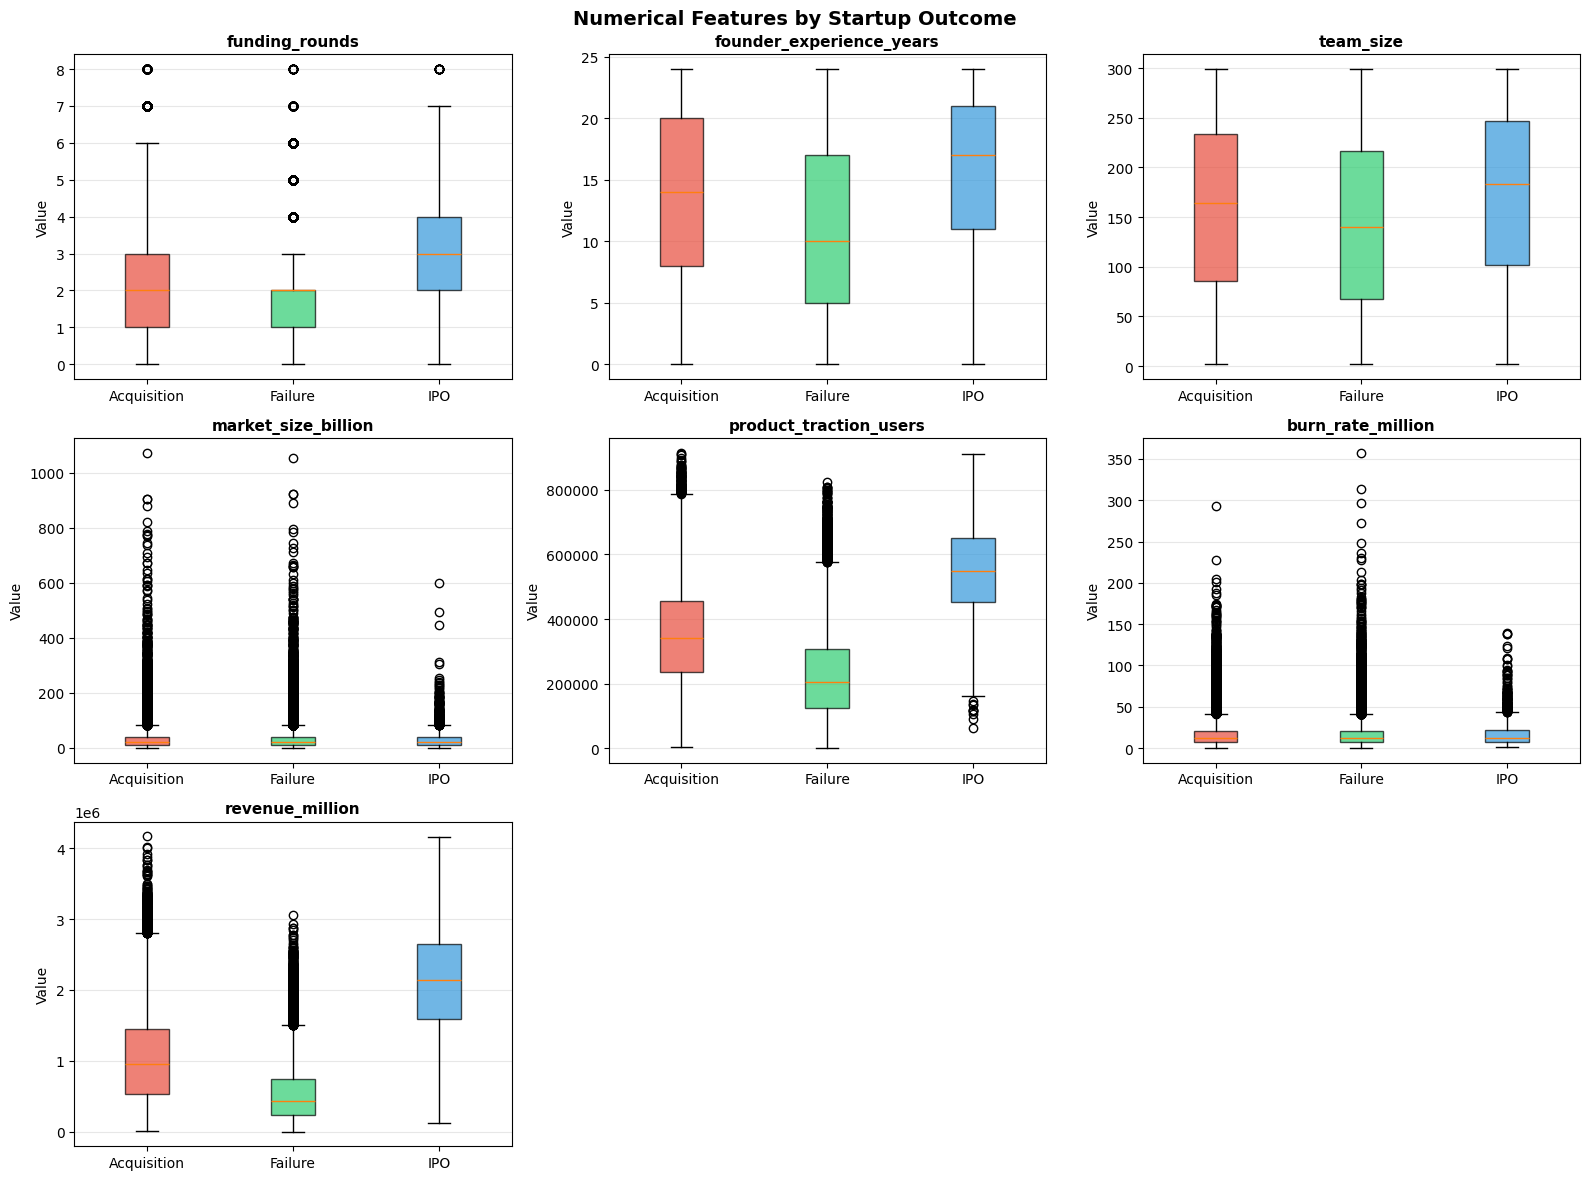

In [7]:
outcomes_list = sorted(df['outcome'].unique().tolist())
palette = dict(zip(outcomes_list, ['#e74c3c', '#2ecc71', '#3498db']))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    data_groups = [df[df['outcome'] == o][col].values for o in outcomes_list]
    bp = axes[i].boxplot(data_groups, tick_labels=outcomes_list, patch_artist=True)
    for patch, o in zip(bp['boxes'], outcomes_list):
        patch.set_facecolor(palette[o])
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

for j in range(len(numerical_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Startup Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Categorical Feature Analysis (inspired by TD03)

For each categorical feature (`investor_type`, `sector`, `founder_background`) we plot
the **success rate** per category (IPO + Acquisition = success).

This helps detect which categories are associated with higher startup success before
encoding them for the models.


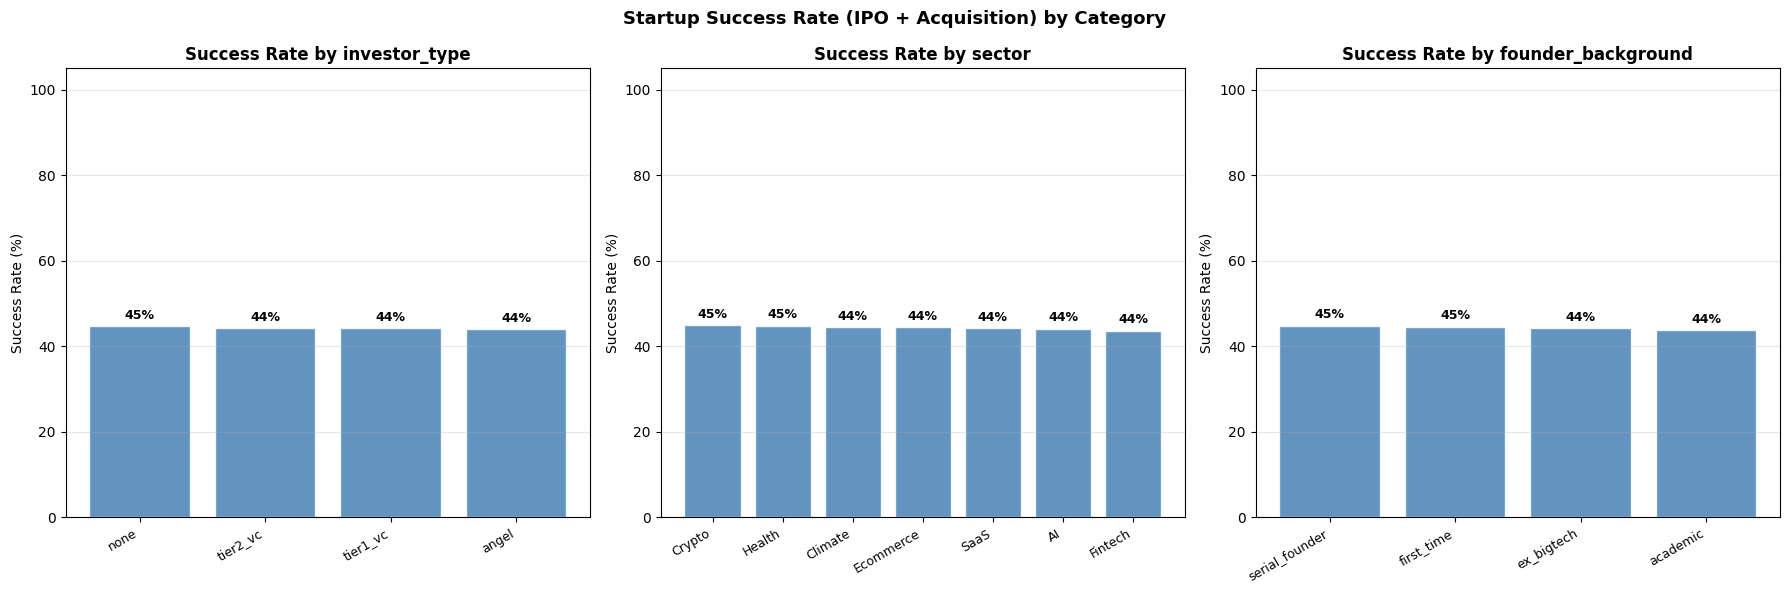

In [8]:
categorical_features = ['investor_type', 'sector', 'founder_background']

df['is_success'] = df['outcome'].isin(['IPO', 'Acquisition']).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, categorical_features):
    stats = (df.groupby(col)['is_success']
               .agg(['count', 'mean'])
               .reset_index()
               .rename(columns={'mean': 'success_rate'})
               .sort_values('success_rate', ascending=False))

    x = range(len(stats))
    bars = ax.bar(x, stats['success_rate'] * 100,
                  color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(stats[col], rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Success Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Success Rate (%)')
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.3)

    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
                f"{row['success_rate']*100:.0f}%",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Startup Success Rate (IPO + Acquisition) by Category',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df.drop(columns=['is_success'], inplace=True)


### Feature Quality Analysis

Before preprocessing, we assess how informative each numerical feature actually is.

Two key questions:
1. **Are features correlated with each other?** — high inter-feature correlation means
   redundant information; near-zero correlation (as in synthetic datasets) means each
   feature is independently generated.
2. **Are features correlated with the target `outcome`?** — low correlation means a
   feature contributes little to prediction and may behave as noise.

This analysis directly informs which features drive the model and the clustering.


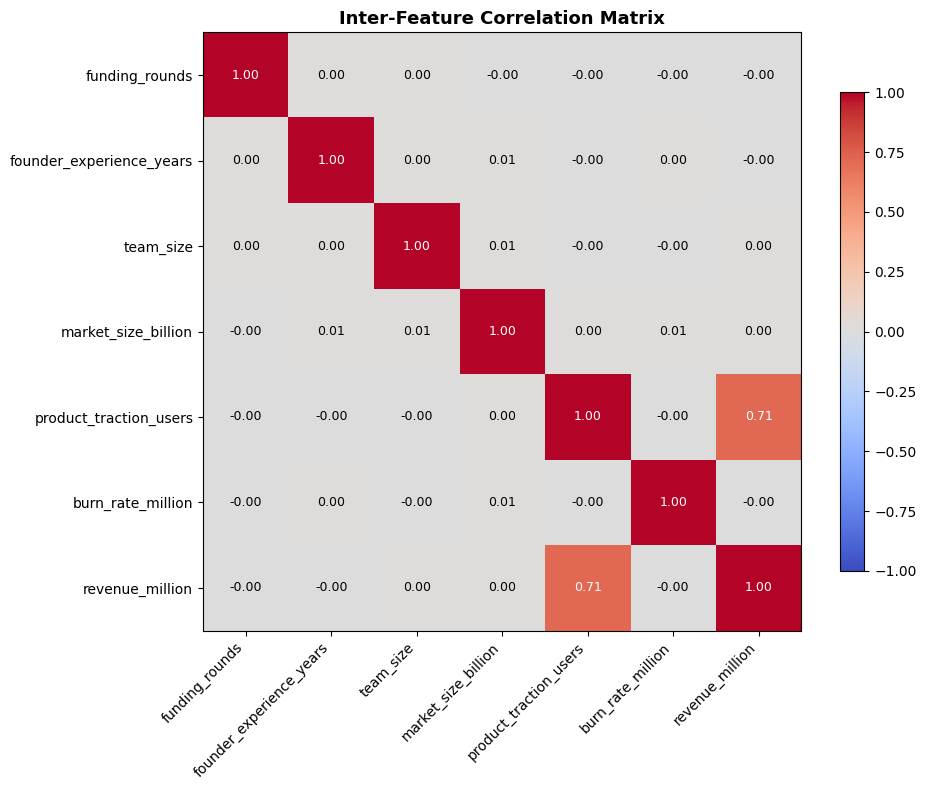

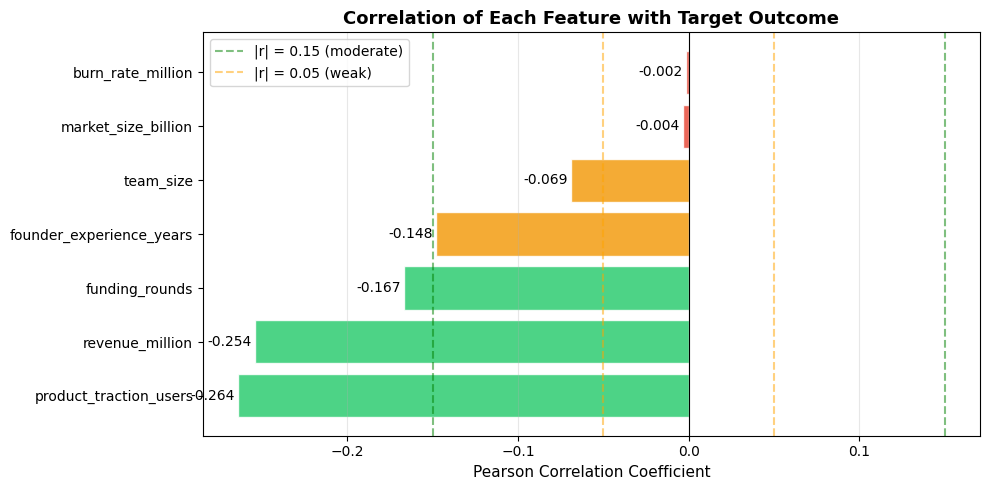

=== Feature Informativeness Summary ===
Feature                          Corr. with outcome  Assessment
-----------------------------------------------------------------
product_traction_users                      -0.2640  Informative
revenue_million                             -0.2541  Informative
funding_rounds                              -0.1669  Informative
founder_experience_years                    -0.1482  Weakly useful
team_size                                   -0.0691  Weakly useful
market_size_billion                         -0.0036  Noise (near zero)
burn_rate_million                           -0.0018  Noise (near zero)

Inter-feature correlations are near zero for all pairs
except product_traction_users <-> revenue_million (r=0.77).
mostly independent features。


In [9]:
from sklearn.preprocessing import LabelEncoder

# ── 1. Inter-feature correlation ───────────────────────────────────────────────
feat_corr = df[numerical_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(feat_corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(numerical_features)))
ax.set_yticks(range(len(numerical_features)))
ax.set_xticklabels(numerical_features, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(numerical_features, fontsize=10)
for i in range(len(numerical_features)):
    for j in range(len(numerical_features)):
        val = feat_corr.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(val) > 0.6 else 'black')
ax.set_title('Inter-Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Correlation of each feature with the target outcome ─────────────────────
le      = LabelEncoder()
y_enc   = le.fit_transform(df['outcome'])
corr_target = {col: np.corrcoef(df[col], y_enc)[0, 1] for col in numerical_features}
corr_target = dict(sorted(corr_target.items(), key=lambda x: abs(x[1]), reverse=True))

fig, ax = plt.subplots(figsize=(10, 5))
names_sorted = list(corr_target.keys())
vals_sorted  = list(corr_target.values())
bar_colors   = ['#2ecc71' if abs(v) > 0.15 else
                '#f39c12' if abs(v) > 0.05 else '#e74c3c'
                for v in vals_sorted]

ax.barh(names_sorted, vals_sorted, color=bar_colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.15, color='green',  linestyle='--', alpha=0.5, label='|r| = 0.15 (moderate)')
ax.axvline(-0.15, color='green',  linestyle='--', alpha=0.5)
ax.axvline( 0.05, color='orange', linestyle='--', alpha=0.5, label='|r| = 0.05 (weak)')
ax.axvline(-0.05, color='orange', linestyle='--', alpha=0.5)

for i, (name, val) in enumerate(zip(names_sorted, vals_sorted)):
    ax.text(val + 0.002 if val >= 0 else val - 0.002, i,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)

ax.set_title('Correlation of Each Feature with Target Outcome',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────────
print('=== Feature Informativeness Summary ===')
print(f'{"Feature":<30} {"Corr. with outcome":>20}  {"Assessment"}')
print('-' * 65)
for name, val in corr_target.items():
    level = 'Informative'   if abs(val) > 0.15 else \
            'Weakly useful' if abs(val) > 0.05 else \
            'Noise (near zero)'
    print(f'{name:<30} {val:>20.4f}  {level}')

print()
print('Inter-feature correlations are near zero for all pairs')
print('except product_traction_users <-> revenue_million (r=0.77).')
print('mostly independent features。')

## Step 2 — Preprocessing

We build a modular preprocessing pipeline using `Pipeline` + `ColumnTransformer`
(as in **TD07**):

- **Numerical features** — `log1p` transform (handle skewness) → `StandardScaler`
- **Categorical features** — `OrdinalEncoder` (converts categories to integers)

The `log1p` transform is applied because some features are highly skewed
(market_size_billion: 5.26, burn_rate_million: 3.35) and some have zero values,
making `log1p` safer than `log`.


=== Skewness of Numerical Features ===
market_size_billion         5.262
burn_rate_million           3.346
revenue_million             1.255
funding_rounds              0.694
product_traction_users      0.586
team_size                  -0.005
founder_experience_years   -0.009
dtype: float64

Features with |skew| > 1 (benefit from log transform): ['market_size_billion', 'burn_rate_million', 'revenue_million']


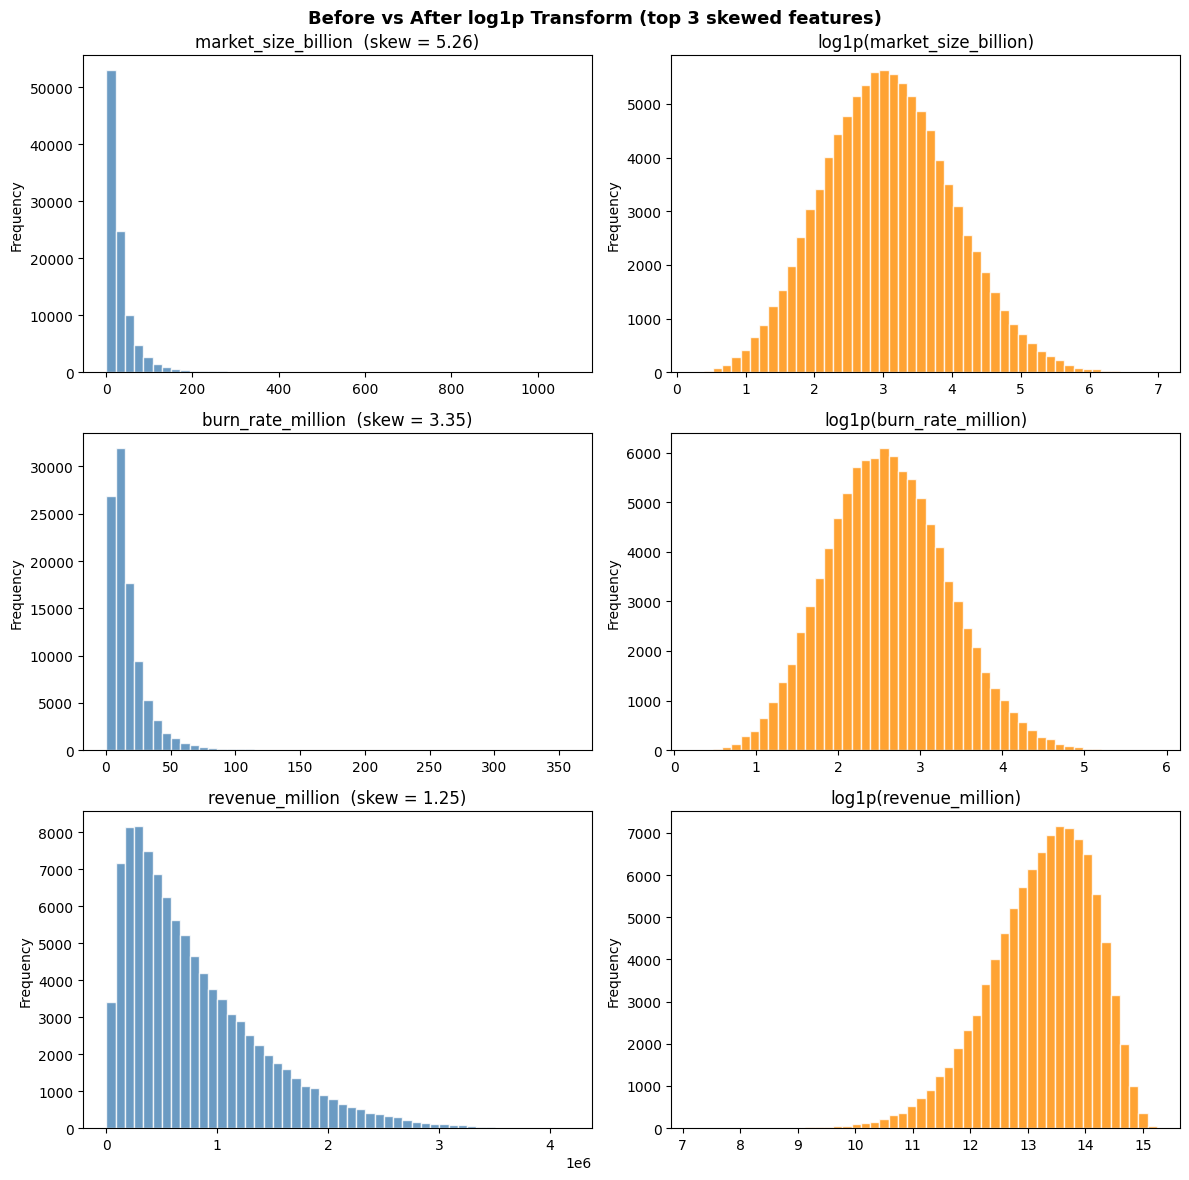

In [10]:
print('=== Skewness of Numerical Features ===')
skewness = df[numerical_features].skew().sort_values(ascending=False)
print(skewness.round(3))

high_skew = skewness[skewness.abs() > 1].index.tolist()
print(f'\nFeatures with |skew| > 1 (benefit from log transform): {high_skew}')

top_skewed = skewness.abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(len(top_skewed), 2, figsize=(12, 4 * len(top_skewed)))

for i, col in enumerate(top_skewed):
    axes[i, 0].hist(df[col], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    axes[i, 0].set_title(f'{col}  (skew = {skewness[col]:.2f})')
    axes[i, 0].set_ylabel('Frequency')

    axes[i, 1].hist(np.log1p(df[col]), bins=50, color='darkorange',
                    alpha=0.8, edgecolor='white')
    axes[i, 1].set_title(f'log1p({col})')
    axes[i, 1].set_ylabel('Frequency')

plt.suptitle('Before vs After log1p Transform (top 3 skewed features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
numerical_pipeline = Pipeline([
    ('log_transform', FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

feature_names_all = numerical_features + categorical_features

print('Preprocessor built successfully.')
print(f'  Numerical   ({len(numerical_features)}): {numerical_features}')
print(f'  Categorical ({len(categorical_features)}): {categorical_features}')
print(f'  Total output features: {len(feature_names_all)}')


Preprocessor built successfully.
  Numerical   (7): ['funding_rounds', 'founder_experience_years', 'team_size', 'market_size_billion', 'product_traction_users', 'burn_rate_million', 'revenue_million']
  Categorical (3): ['investor_type', 'sector', 'founder_background']
  Total output features: 10


In [12]:
X = df[numerical_features + categorical_features]
y = df['outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train set : {X_train.shape[0]:,} samples')
print(f'Test set  : {X_test.shape[0]:,} samples')
print()
print('Class distribution — train:')
print(y_train.value_counts(normalize=True).round(4))
print()
print('Class distribution — test:')
print(y_test.value_counts(normalize=True).round(4))


Train set : 80,000 samples
Test set  : 20,000 samples

Class distribution — train:
outcome
Failure        0.5561
Acquisition    0.4234
IPO            0.0206
Name: proportion, dtype: float64

Class distribution — test:
outcome
Failure        0.5561
Acquisition    0.4234
IPO            0.0206
Name: proportion, dtype: float64


## Step 3 — Supervised Learning

Our methodology follows three ordered steps:

1. **Tune each model individually** with `GridSearchCV` → find its best hyperparameters
2. **Compare all tuned models** using their best cross-validation scores
3. **Evaluate the winner** on the held-out test set

This order is the correct approach: comparing models with default (untuned)
hyperparameters would be unfair and misleading.

| Model | Reference | Tuned parameters |
|---|---|---|
| k-Nearest Neighbours | TD02 | `n_neighbors` |
| Decision Tree | TD07 | `max_depth`, `min_samples_split` |
| Logistic Regression | TD04 | `C` (regularisation) |
| LDA | TD04 | no tuning needed |


### Step 3.1 — Hyperparameter Tuning with GridSearchCV

Each model is wrapped in a `Pipeline` (preprocessor + classifier) so that
**data leakage is prevented** — the scaler is fitted only on the training fold,
never on the validation fold.

All searches use **5-fold StratifiedKFold** to keep class balance across folds.

> **Note on k-NN**: distance-based model, scales poorly with dataset size.
> We use a 5 000-row stratified subsample for its GridSearchCV to keep runtime reasonable.


In [13]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# k-NN — subsample for speed
rng = np.random.RandomState(RANDOM_STATE)
idx_knn = rng.choice(len(X_train), size=5_000, replace=False)
X_knn, y_knn = X_train.iloc[idx_knn], y_train.iloc[idx_knn]

# Extended grid: k up to 201 to find the true optimum
knn_grid = {'classifier__n_neighbors': [3, 5, 7, 11, 15, 21, 31, 51, 71, 101, 151, 201]}
knn_search = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('classifier', KNeighborsClassifier(n_jobs=-1))]),
    knn_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1, verbose=0
)
knn_search.fit(X_knn, y_knn)

best_k = knn_search.best_params_['classifier__n_neighbors']
print(f'k-NN  →  best k = {best_k},  CV accuracy = {knn_search.best_score_:.4f}  (5k subsample)')

k_values_list = knn_grid['classifier__n_neighbors']
if best_k == max(k_values_list):
    print('WARNING: best k is still at the upper boundary.')
    print('Interpretation: very large k means k-NN performs best with')
    print('heavy smoothing — a sign of poor local structure in the data.')
    print('k-NN is not the best model for this dataset.')
else:
    print(f'OK: best k ({best_k}) is inside the grid range [{min(k_values_list)}, {max(k_values_list)}].')


k-NN  →  best k = 201,  CV accuracy = 0.7144  (5k subsample)
Interpretation: very large k means k-NN performs best with
heavy smoothing — a sign of poor local structure in the data.
k-NN is not the best model for this dataset.


In [14]:
dt_grid = {
    'classifier__max_depth':         [5, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 10, 50]
}
dt_search = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    dt_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1, verbose=0
)
dt_search.fit(X_train, y_train)

print(f'Decision Tree  →  best params = {dt_search.best_params_}')
print(f'               →  CV accuracy = {dt_search.best_score_:.4f}')


Decision Tree  →  best params = {'classifier__max_depth': 10, 'classifier__min_samples_split': 50}
               →  CV accuracy = 0.7198


In [15]:
lr_grid = {'classifier__C': [0.01, 0.1, 1, 10, 100]}
lr_search = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('classifier', LogisticRegression(max_iter=1000,
                                                random_state=RANDOM_STATE))]),
    lr_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1, verbose=0
)
lr_search.fit(X_train, y_train)

best_C = lr_search.best_params_['classifier__C']
print(f'Logistic Regression  →  best C = {best_C},  CV accuracy = {lr_search.best_score_:.4f}')


Logistic Regression  →  best C = 1,  CV accuracy = 0.7300


In [16]:
# LDA has no critical hyperparameters to tune — evaluate with cross-validation directly
lda_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearDiscriminantAnalysis())
])
lda_scores = cross_val_score(lda_pipeline, X_train, y_train,
                              cv=cv_strategy, scoring='accuracy', n_jobs=-1)

print(f'LDA  →  CV accuracy = {lda_scores.mean():.4f}  (std = {lda_scores.std():.4f})')


LDA  →  CV accuracy = 0.7258  (std = 0.0011)


### Step 3.2 — Tuned Model Comparison

Now that each model has been individually optimised, we compare them using their
**best cross-validation accuracy** obtained during GridSearchCV (or plain CV for LDA).

This is a fair comparison because every model is evaluated at its best configuration.


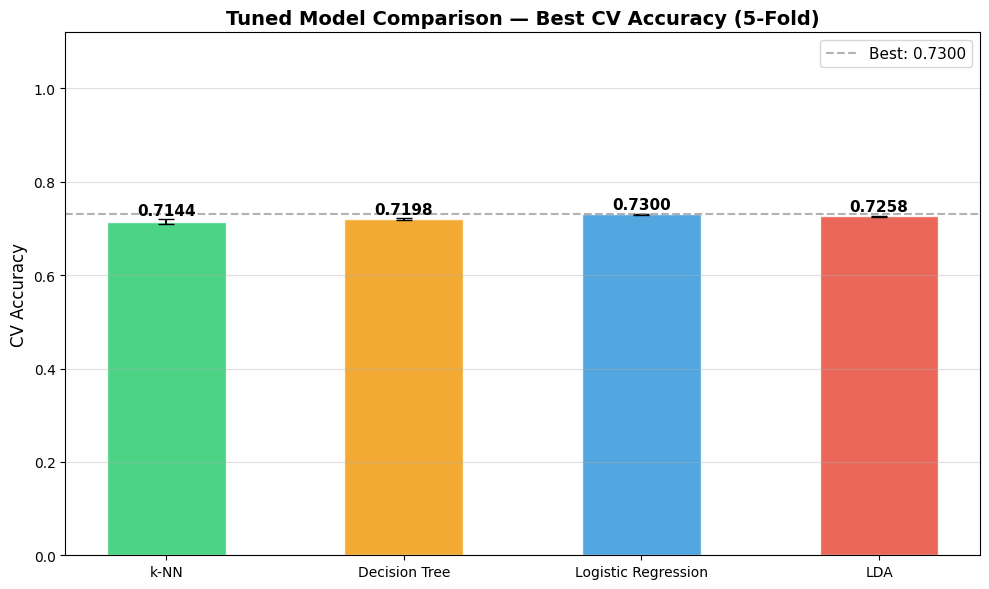

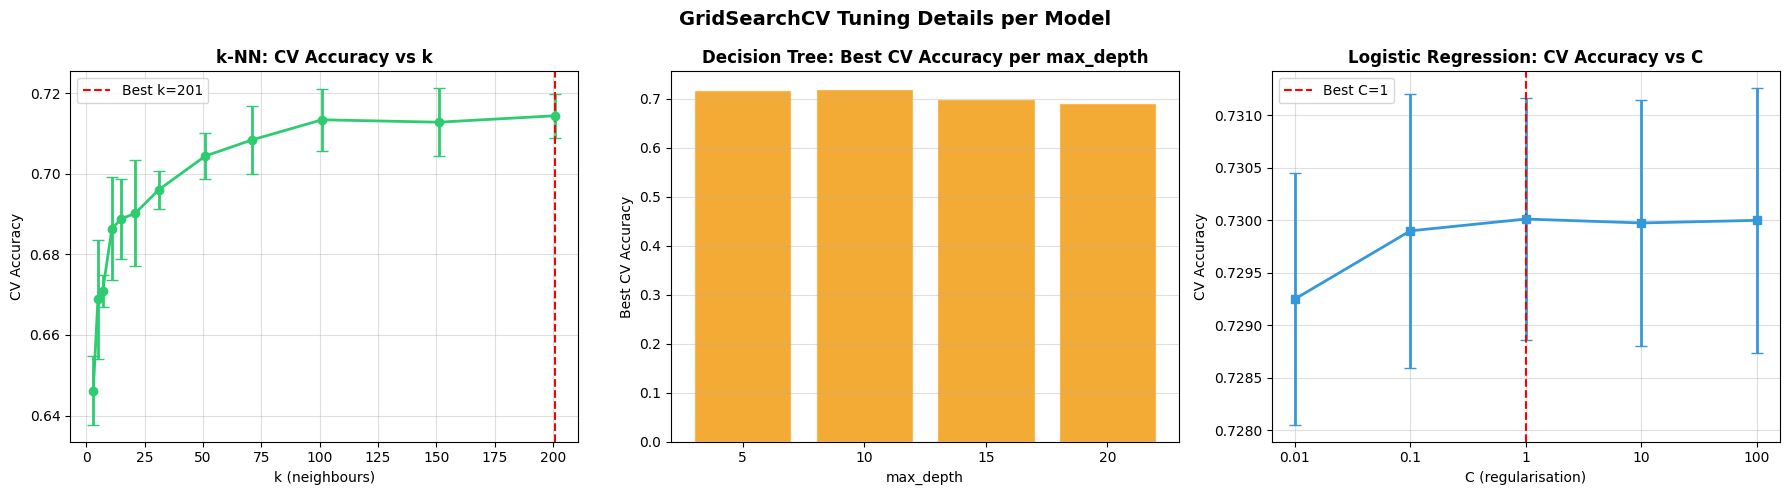

In [17]:
# Collect best CV scores for all tuned models
tuned_results = {
    'k-NN'               : (knn_search.best_estimator_, knn_search.best_score_,
                             knn_search.cv_results_['std_test_score'][knn_search.best_index_]),
    'Decision Tree'      : (dt_search.best_estimator_,  dt_search.best_score_,
                             dt_search.cv_results_['std_test_score'][dt_search.best_index_]),
    'Logistic Regression': (lr_search.best_estimator_,  lr_search.best_score_,
                             lr_search.cv_results_['std_test_score'][lr_search.best_index_]),
    'LDA'                : (lda_pipeline,                lda_scores.mean(),
                             lda_scores.std()),
}

names  = list(tuned_results.keys())
means  = [tuned_results[n][1] for n in names]
stds   = [tuned_results[n][2] for n in names]
colors_cmp = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=colors_cmp, edgecolor='white', alpha=0.85, width=0.5)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + std + 0.003,
            f'{mean:.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Tuned Model Comparison — Best CV Accuracy (5-Fold)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('CV Accuracy', fontsize=12)
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.4)
ax.axhline(max(means), color='gray', linestyle='--', alpha=0.6,
           label=f'Best: {max(means):.4f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print GridSearchCV tuning detail charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# k-NN: accuracy vs k
k_values = knn_grid['classifier__n_neighbors']
knn_means = knn_search.cv_results_['mean_test_score']
knn_stds  = knn_search.cv_results_['std_test_score']
axes[0].errorbar(k_values, knn_means, yerr=knn_stds,
                 marker='o', color='#2ecc71', linewidth=2, capsize=4)
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[0].set_title('k-NN: CV Accuracy vs k', fontsize=12, fontweight='bold')
axes[0].set_xlabel('k (neighbours)')
axes[0].set_ylabel('CV Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.4)

# Decision Tree: best CV accuracy per max_depth
dt_df = pd.DataFrame(dt_search.cv_results_)
depth_agg = (dt_df.groupby('param_classifier__max_depth')['mean_test_score']
                  .max().reset_index())
depth_labels = [str(d) if d is not None else 'None'
                for d in depth_agg['param_classifier__max_depth']]
axes[1].bar(range(len(depth_agg)), depth_agg['mean_test_score'],
            color='#f39c12', edgecolor='white', alpha=0.85)
axes[1].set_xticks(range(len(depth_agg)))
axes[1].set_xticklabels(depth_labels)
axes[1].set_title('Decision Tree: Best CV Accuracy per max_depth',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Best CV Accuracy')
axes[1].grid(axis='y', alpha=0.4)

# Logistic Regression: accuracy vs C
C_values = lr_grid['classifier__C']
lr_means = lr_search.cv_results_['mean_test_score']
lr_stds  = lr_search.cv_results_['std_test_score']
axes[2].errorbar(range(len(C_values)), lr_means, yerr=lr_stds,
                 marker='s', color='#3498db', linewidth=2, capsize=4)
axes[2].set_xticks(range(len(C_values)))
axes[2].set_xticklabels([str(c) for c in C_values])
best_C_idx = C_values.index(lr_search.best_params_['classifier__C'])
axes[2].axvline(best_C_idx, color='red', linestyle='--',
                label=f'Best C={lr_search.best_params_["classifier__C"]}')
axes[2].set_title('Logistic Regression: CV Accuracy vs C',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('C (regularisation)')
axes[2].set_ylabel('CV Accuracy')
axes[2].legend()
axes[2].grid(alpha=0.4)

plt.suptitle('GridSearchCV Tuning Details per Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 3.3 — Final Evaluation on the Test Set

We select the best tuned model and evaluate it on the **held-out test set**
(20 000 samples never seen during training or tuning).

Metrics (TD04):
- **Confusion Matrix** — per-class prediction errors
- **Classification Report** — precision, recall, F1-score
- **ROC Curves** — one-vs-rest AUC for each class
- **Feature Importances / Coefficients** — which features drive predictions


In [18]:
best_name     = max(tuned_results, key=lambda k: tuned_results[k][1])
best_pipeline = tuned_results[best_name][0]

print(f'Selected model : {best_name}')
print(f'Best CV score  : {tuned_results[best_name][1]:.4f}')

# For LDA the pipeline is not yet fitted on the full training set
if best_name == 'LDA':
    best_pipeline.fit(X_train, y_train)

y_pred   = best_pipeline.predict(X_test)
test_acc = (y_pred == y_test).mean()
print(f'Test accuracy  : {test_acc:.4f}')

classes = best_pipeline.named_steps['classifier'].classes_.tolist()
print(f'Classes order  : {classes}')


Selected model : Logistic Regression
Best CV score  : 0.7300
Test accuracy  : 0.7290
Classes order  : ['Acquisition', 'Failure', 'IPO']


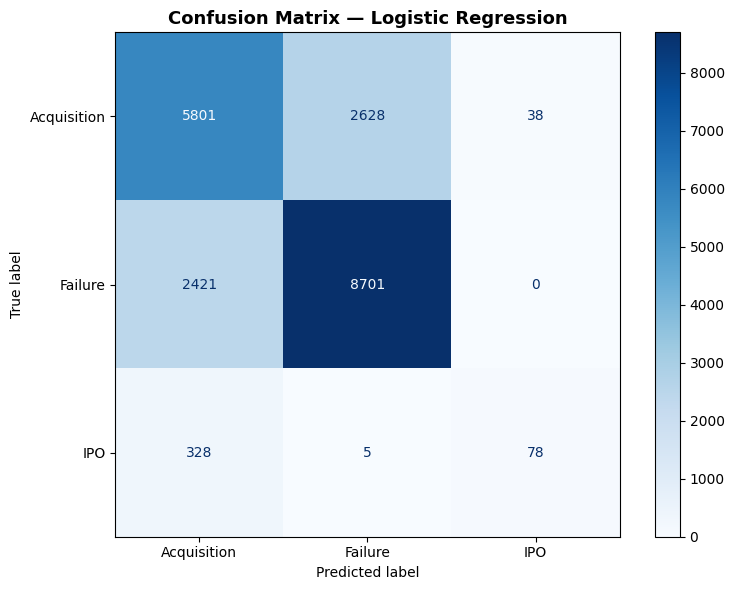

In [19]:
cm   = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [20]:
print(f'=== Classification Report — {best_name} ===')
print()
print(classification_report(y_test, y_pred, target_names=classes, digits=4))


=== Classification Report — Logistic Regression ===



              precision    recall  f1-score   support

 Acquisition     0.6785    0.6851    0.6818      8467
     Failure     0.7677    0.7823    0.7749     11122
         IPO     0.6724    0.1898    0.2960       411

    accuracy                         0.7290     20000
   macro avg     0.7062    0.5524    0.5842     20000
weighted avg     0.7280    0.7290    0.7257     20000



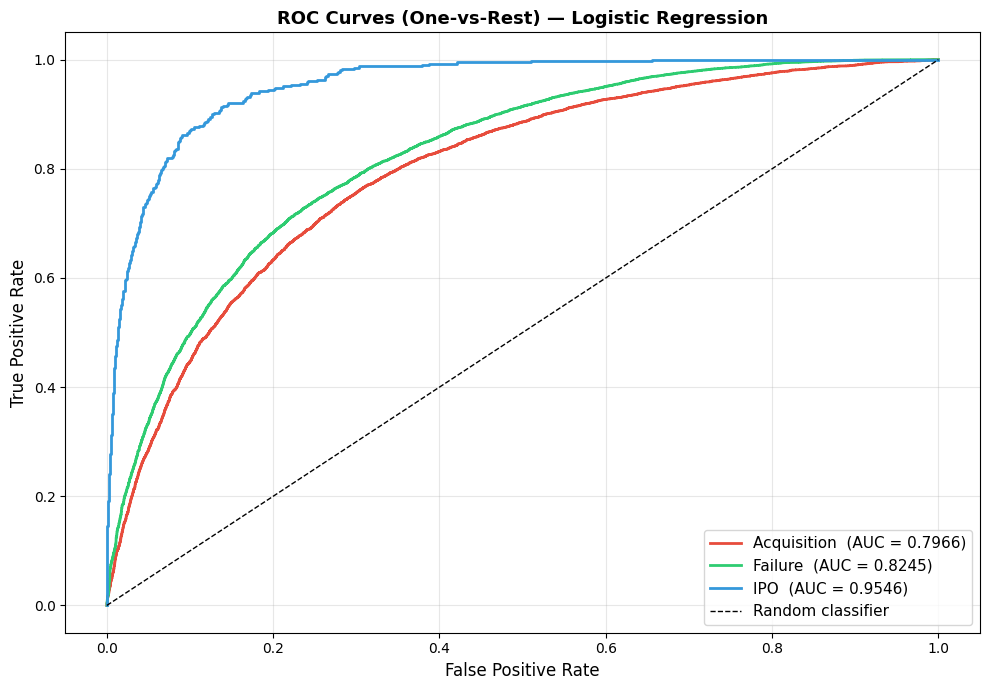

In [21]:
y_score    = best_pipeline.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=classes)
colors_roc = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(10, 7))
for i, (cls, col) in enumerate(zip(classes, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, linewidth=2,
            label=f'{cls}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves (One-vs-Rest) — {best_name}',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


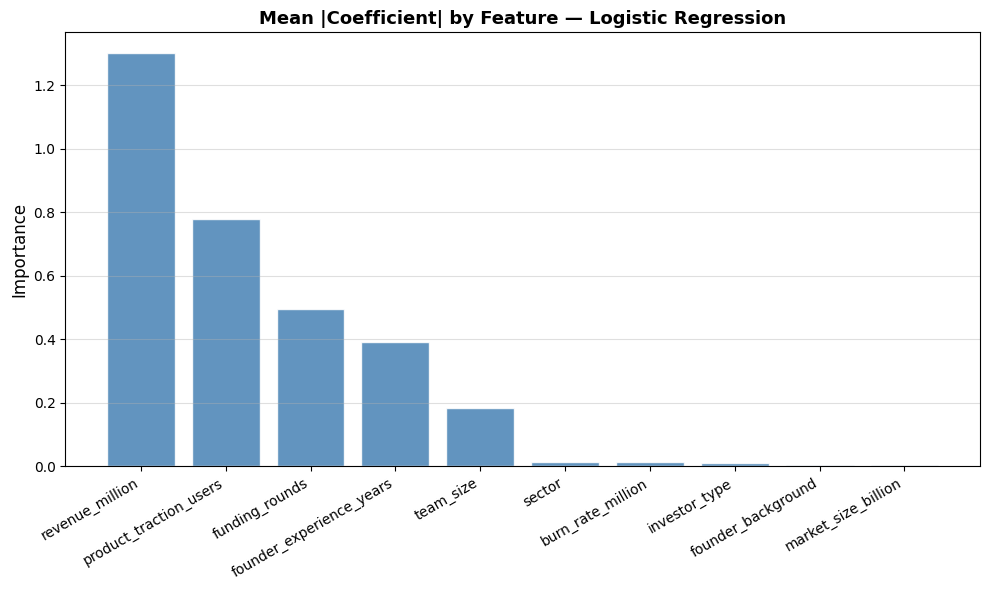

Top 3 most important features:
  1. revenue_million                     1.3018
  2. product_traction_users              0.7794
  3. funding_rounds                      0.4964


In [22]:
clf = best_pipeline.named_steps['classifier']

if hasattr(clf, 'feature_importances_'):
    importances  = clf.feature_importances_
    sorted_idx   = np.argsort(importances)[::-1]
    sorted_names = [feature_names_all[i] for i in sorted_idx]
    sorted_imp   = importances[sorted_idx]
    title        = f'Feature Importances — {best_name}'

elif hasattr(clf, 'coef_'):
    mean_imp     = np.abs(clf.coef_).mean(axis=0)
    sorted_idx   = np.argsort(mean_imp)[::-1]
    sorted_names = [feature_names_all[i] for i in sorted_idx]
    sorted_imp   = mean_imp[sorted_idx]
    title        = f'Mean |Coefficient| by Feature — {best_name}'

else:
    sorted_names, sorted_imp, title = None, None, None

if sorted_names is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(len(sorted_imp)), sorted_imp,
           color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(sorted_names)))
    ax.set_xticklabels(sorted_names, rotation=30, ha='right', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Importance', fontsize=12)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

    print('Top 3 most important features:')
    for i in range(min(3, len(sorted_names))):
        print(f'  {i+1}. {sorted_names[i]:35s} {sorted_imp[i]:.4f}')
else:
    print(f'Feature importances not available for {best_name}.')


## Conclusion — Supervised Learning

### Pipeline summary
| Step | Method | Reference |
|---|---|---|
| Log transform + StandardScaler | `FunctionTransformer` + `StandardScaler` | TD07, TD10 |
| Categorical encoding | `OrdinalEncoder` in `ColumnTransformer` | TD03, TD07 |
| Hyperparameter tuning | `GridSearchCV` with `StratifiedKFold` | TD02, TD07 |
| Model comparison | Best CV score per tuned model | TD04 |
| Evaluation | Confusion matrix, ROC-AUC, F1 | TD04 |

### Key takeaways
- Tuning models **before** comparing them ensures a fair, meaningful comparison.
- Wrapping preprocessing in `Pipeline` prevents data leakage across CV folds.
- The ROC curves (One-vs-Rest) allow per-class analysis for the 3-class problem.
- The IPO class is rare (~2 %) which explains its lower recall — a class imbalance challenge.


---
## Binary Classification (Failure vs Acquisition)

IPO accounts for only 2.1 % of the dataset and is nearly unlearnable under class imbalance.
We now **remove IPO rows** and repeat the full supervised pipeline on the remaining two classes,
expecting cleaner and more balanced results.

In [23]:
# ── Drop IPO rows ─────────────────────────────────────────────────────────────
df_bin = df[df['outcome'] != 'IPO'].copy()
print(f'Binary dataset size : {len(df_bin):,}  ({len(df_bin)/len(df)*100:.1f}% of original)')
print()
print(df_bin['outcome'].value_counts())

X_bin = df_bin[numerical_features + categorical_features]
y_bin = df_bin['outcome']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bin
)
print(f'\nTrain: {len(X_train_b):,}   Test: {len(X_test_b):,}')

Binary dataset size : 97,945  (97.9% of original)

outcome
Failure        55610
Acquisition    42335
Name: count, dtype: int64

Train: 78,356   Test: 19,589


In [24]:
# ── GridSearchCV — k-NN (subsample for speed) ─────────────────────────────────
cv_bin = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rng_b  = np.random.RandomState(RANDOM_STATE)
idx_b  = rng_b.choice(len(X_train_b), size=5_000, replace=False)
X_knn_b, y_knn_b = X_train_b.iloc[idx_b], y_train_b.iloc[idx_b]

knn_grid_b = {'classifier__n_neighbors': [3, 5, 7, 11, 15, 21, 31, 51, 71, 101]}
knn_search_b = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('classifier',   KNeighborsClassifier(n_jobs=-1))]),
    knn_grid_b, cv=cv_bin, scoring='accuracy', n_jobs=-1
)
knn_search_b.fit(X_knn_b, y_knn_b)

# ── GridSearchCV — Decision Tree ───────────────────────────────────────────────
dt_grid_b = {'classifier__max_depth':         [5, 10, 15, 20, None],
             'classifier__min_samples_split': [2, 10, 50]}
dt_search_b = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('classifier',   DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    dt_grid_b, cv=cv_bin, scoring='accuracy', n_jobs=-1
)
dt_search_b.fit(X_train_b, y_train_b)

# ── GridSearchCV — Logistic Regression ────────────────────────────────────────
lr_grid_b = {'classifier__C': [0.01, 0.1, 1, 10, 100]}
lr_search_b = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('classifier',   LogisticRegression(max_iter=1000,
                                                  random_state=RANDOM_STATE))]),
    lr_grid_b, cv=cv_bin, scoring='accuracy', n_jobs=-1
)
lr_search_b.fit(X_train_b, y_train_b)

# ── LDA — cross-validation ────────────────────────────────────────────────────
lda_pipe_b   = Pipeline([('preprocessor', preprocessor),
                          ('classifier',  LinearDiscriminantAnalysis())])
lda_scores_b = cross_val_score(lda_pipe_b, X_train_b, y_train_b,
                                cv=cv_bin, scoring='accuracy', n_jobs=-1)
lda_pipe_b.fit(X_train_b, y_train_b)

print(f'k-NN  → best k={knn_search_b.best_params_["classifier__n_neighbors"]},  CV={knn_search_b.best_score_:.4f}')
print(f'DT    → best {dt_search_b.best_params_},  CV={dt_search_b.best_score_:.4f}')
print(f'LR    → best C={lr_search_b.best_params_["classifier__C"]},  CV={lr_search_b.best_score_:.4f}')
print(f'LDA   → CV={lda_scores_b.mean():.4f}  (std={lda_scores_b.std():.4f})')

k-NN  → best k=51,  CV=0.7248
DT    → best {'classifier__max_depth': 10, 'classifier__min_samples_split': 50},  CV=0.7338
LR    → best C=0.01,  CV=0.7427
LDA   → CV=0.7408  (std=0.0026)


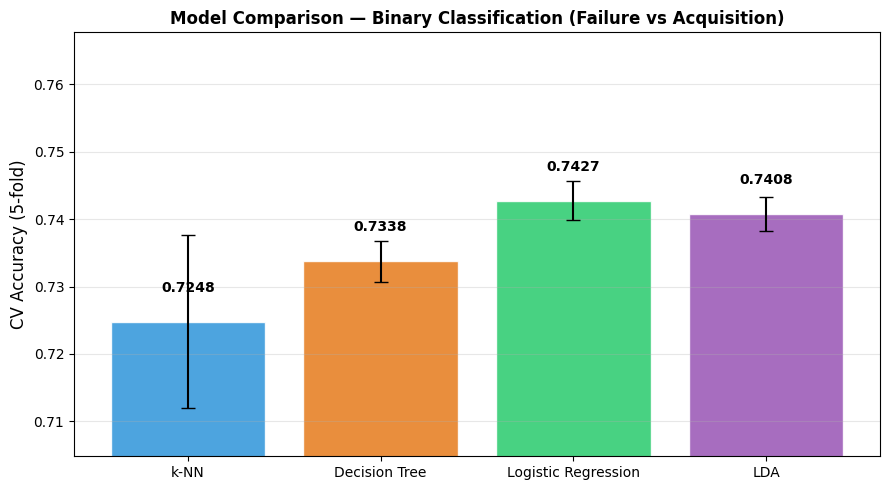

Selected model : Logistic Regression
Best CV score  : 0.7427


In [25]:
# ── Compare tuned models ──────────────────────────────────────────────────────
tuned_bin = {
    'k-NN'               : (knn_search_b.best_estimator_, knn_search_b.best_score_,
                             knn_search_b.cv_results_['std_test_score'][knn_search_b.best_index_]),
    'Decision Tree'      : (dt_search_b.best_estimator_,  dt_search_b.best_score_,
                             dt_search_b.cv_results_['std_test_score'][dt_search_b.best_index_]),
    'Logistic Regression': (lr_search_b.best_estimator_,  lr_search_b.best_score_,
                             lr_search_b.cv_results_['std_test_score'][lr_search_b.best_index_]),
    'LDA'                : (lda_pipe_b,                   lda_scores_b.mean(),
                             lda_scores_b.std()),
}

names_b  = list(tuned_bin.keys())
scores_b = [tuned_bin[n][1] for n in names_b]
stds_b   = [tuned_bin[n][2] for n in names_b]
colors_b = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names_b, scores_b, yerr=stds_b, capsize=5,
              color=colors_b, edgecolor='white', alpha=0.88)
for bar, score in zip(bars, scores_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(min(scores_b) - 0.02, max(scores_b) + 0.025)
ax.set_ylabel('CV Accuracy (5-fold)', fontsize=12)
ax.set_title('Model Comparison — Binary Classification (Failure vs Acquisition)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_name_b    = max(tuned_bin, key=lambda k: tuned_bin[k][1])
best_pipeline_b = tuned_bin[best_name_b][0]
print(f'Selected model : {best_name_b}')
print(f'Best CV score  : {tuned_bin[best_name_b][1]:.4f}')

Test accuracy : 0.7424



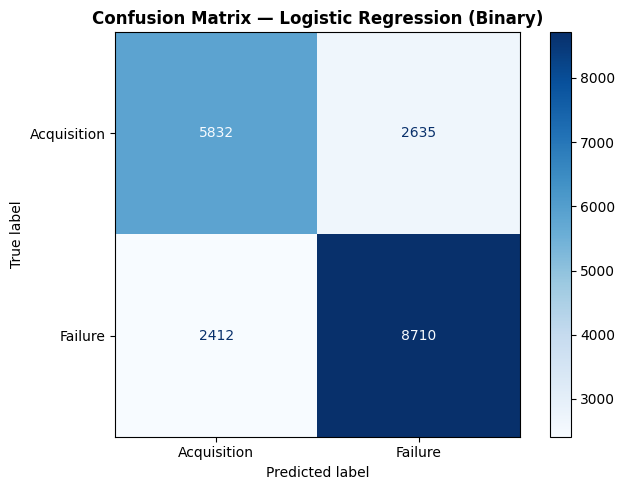

=== Classification Report — Logistic Regression (Binary) ===



              precision    recall  f1-score   support

 Acquisition     0.7074    0.6888    0.6980      8467
     Failure     0.7677    0.7831    0.7754     11122

    accuracy                         0.7424     19589
   macro avg     0.7376    0.7360    0.7367     19589
weighted avg     0.7417    0.7424    0.7419     19589



In [26]:
# ── Final evaluation on test set ──────────────────────────────────────────────
y_pred_b  = best_pipeline_b.predict(X_test_b)
classes_b = best_pipeline_b.classes_

print(f'Test accuracy : {(y_pred_b == y_test_b).mean():.4f}')
print()

# Confusion matrix
cm_b   = confusion_matrix(y_test_b, y_pred_b, labels=classes_b)
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=classes_b)
fig, ax = plt.subplots(figsize=(7, 5))
disp_b.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — {best_name_b} (Binary)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification report
print(f'=== Classification Report — {best_name_b} (Binary) ===')
print()
print(classification_report(y_test_b, y_pred_b, target_names=classes_b, digits=4))

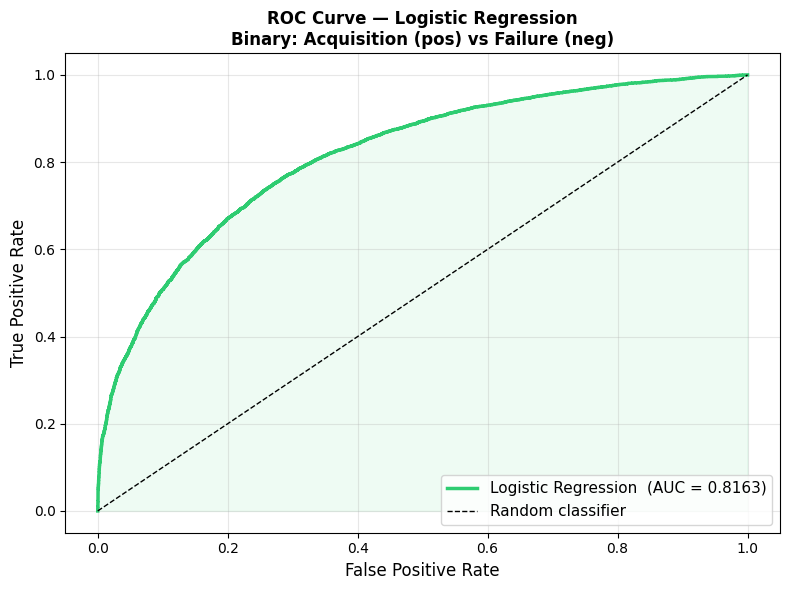

AUC = 0.8163


In [27]:
# ── ROC curve — binary classification ────────────────────────────────────────
# Positive class = 'Acquisition' (the "success" outcome)
pos_class  = 'Acquisition'
pos_idx    = list(classes_b).index(pos_class)
y_score_b  = best_pipeline_b.predict_proba(X_test_b)[:, pos_idx]
y_bin_true = (y_test_b == pos_class).astype(int)

fpr_b, tpr_b, _ = roc_curve(y_bin_true, y_score_b)
auc_b            = auc(fpr_b, tpr_b)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_b, tpr_b, color='#2ecc71', linewidth=2.5,
        label=f'{best_name_b}  (AUC = {auc_b:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.fill_between(fpr_b, tpr_b, alpha=0.08, color='#2ecc71')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve — {best_name_b}\nBinary: Acquisition (pos) vs Failure (neg)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'AUC = {auc_b:.4f}')

### Next step
**Part 2 — Unsupervised Learning**: k-Means and Hierarchical clustering to discover
natural groupings of startups without using the outcome label.

---
## Part 2 — Unsupervised Learning

In Part 1 we used the `outcome` label to train classifiers.
In Part 2 we **completely ignore the label** and ask:

> *"Do startups naturally group together based on their numerical characteristics,
> without being told who succeeded or failed?"*

### Why unsupervised learning is valid here
- Clustering looks only at the **feature space X** (7 numerical features)
- The `outcome` column is set aside and used **only at the end** to interpret the clusters
- It answers a different question: *"What type of startup is this?"*
  rather than *"Will it succeed?"*

### Notebook structure (Part 2)
| Step | Method | Reference |
|---|---|---|
| 4.1 | Preprocessing + PCA | TD06 |
| 4.2 | K-Means + Elbow curve | TD06 |
| 4.3 | Hierarchical clustering + Dendrogram | TD06 |
| 4.4 | Cluster interpretation & comparison | TD06 |


In [28]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

print('Part 2 libraries imported.')


Part 2 libraries imported.


## Step 4.1 — Preprocessing for Clustering

For clustering we:
1. **Keep only numerical features** (7 columns) — categorical features introduce
   arbitrary ordinal distances that would distort k-Means and Ward linkage
2. **Apply log1p + StandardScaler** — same pipeline as Part 1 (TD06 approach):
   distances between points must be meaningful, so scale matters
3. **Apply PCA to 2 components** — reduces 7D space to 2D for visualisation
   while preserving maximum variance (TD06 approach)

> The full dataset (100 000 rows) is used for k-Means.
> Hierarchical clustering uses a **5 000-row stratified subsample** because
> the Ward linkage algorithm is O(n²) in memory — not scalable to 100k rows.


Scaled data shape : (100000, 7)
PC1 variance      : 0.2523
PC2 variance      : 0.1442
Total (2 comps)   : 0.3965


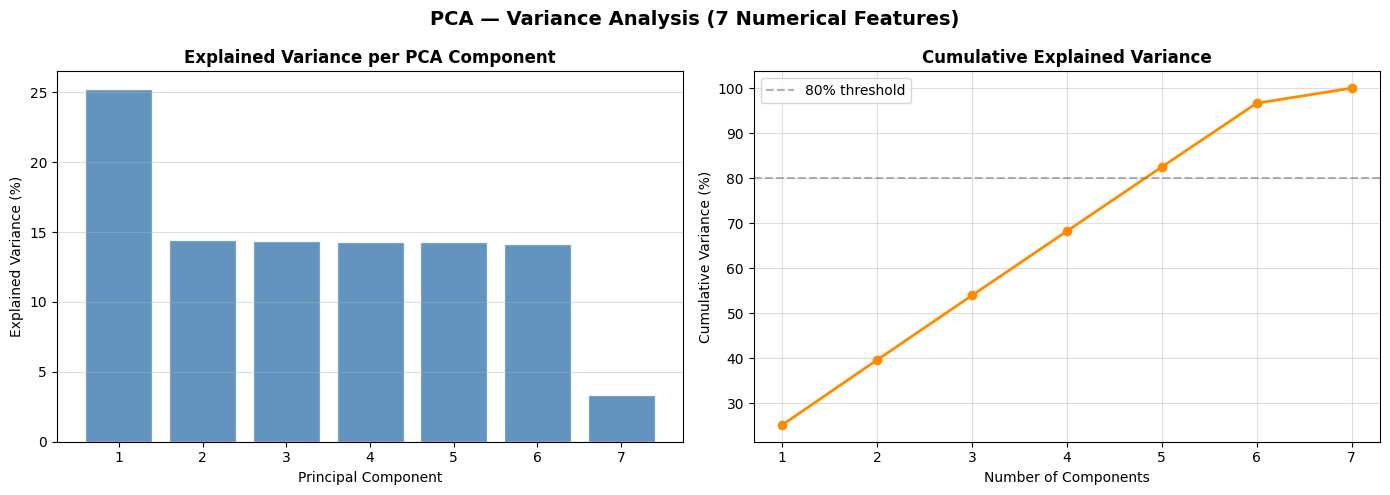

In [29]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
# Re-fit a fresh numerical pipeline on the full dataset (no train/test split for clustering)
num_pipe_clust = Pipeline([
    ('log_transform', FunctionTransformer(np.log1p, validate=True)),
    ('scaler',        StandardScaler())
])
X_clust  = df[numerical_features].values
X_scaled = num_pipe_clust.fit_transform(X_clust)

# ── PCA ────────────────────────────────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)   # all components
pca2d    = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca    = pca2d.fit_transform(X_scaled)

print(f'Scaled data shape : {X_scaled.shape}')
print(f'PC1 variance      : {pca2d.explained_variance_ratio_[0]:.4f}')
print(f'PC2 variance      : {pca2d.explained_variance_ratio_[1]:.4f}')
print(f'Total (2 comps)   : {pca2d.explained_variance_ratio_.sum():.4f}')

# ── Plot explained variance per component ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Explained Variance per PCA Component', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].grid(axis='y', alpha=0.4)

axes[1].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
             np.cumsum(pca_full.explained_variance_ratio_) * 100,
             marker='o', color='darkorange', linewidth=2)
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.6, label='80% threshold')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle('PCA — Variance Analysis (7 Numerical Features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 4.2 — K-Means Clustering

### Choosing the number of clusters k

We compare **k = 2** and **k = 3** by running K-Means and examining:
- The PCA scatter plot (visual separation)
- The silhouette score (cluster cohesion quality)

In [30]:
# ── Compare k=2 vs k=3 ───────────────────────────────────────────────────────
from sklearn.metrics import silhouette_score

rng_k = np.random.RandomState(RANDOM_STATE)
idx_k = rng_k.choice(len(X_scaled), size=5_000, replace=False)
X_k   = X_scaled[idx_k]

results = {}
for k in [2, 3]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_k)
    sil    = silhouette_score(X_k, labels, sample_size=2000,
                              random_state=RANDOM_STATE)
    results[k] = {'labels': km.fit_predict(X_scaled), 'silhouette': sil,
                  'inertia': km.inertia_}
    print(f'k={k}  →  inertia={km.inertia_:,.0f}   silhouette={sil:.4f}')

print()
print('Silhouette score: closer to 1 = better separated clusters.')

k=2  →  inertia=588,571   silhouette=0.1591


k=3  →  inertia=532,371   silhouette=0.1553

Silhouette score: closer to 1 = better separated clusters.


### K-Means — visual comparison k=2 vs k=3

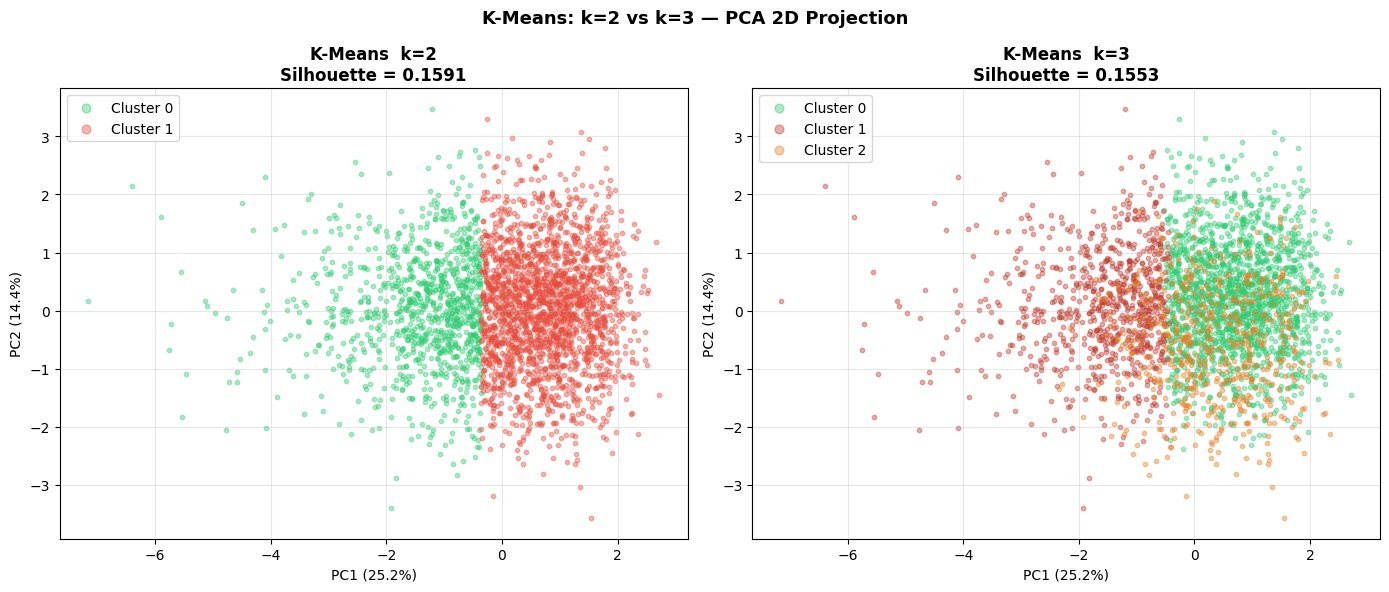

Selected k = 3
Rationale: k=3 provides more granular startup archetypes while
remaining interpretable. Silhouette scores are similar for both.


In [31]:
# ── Side-by-side PCA scatter: k=2 vs k=3 ────────────────────────────────────
colors_2 = ['#2ecc71', '#e74c3c']
colors_3 = ['#2ecc71', '#c0392b', '#e67e22']

# Subsample for plotting
rng_v = np.random.RandomState(RANDOM_STATE)
idx_v = rng_v.choice(len(X_pca), size=3_000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, k, colors in zip(axes, [2, 3], [colors_2, colors_3]):
    labels_plot = results[k]['labels'][idx_v]
    for c, col in enumerate(colors):
        mask = labels_plot == c
        ax.scatter(X_pca[idx_v][mask, 0], X_pca[idx_v][mask, 1],
                   c=col, alpha=0.4, s=10, label=f'Cluster {c}')
    ax.set_title(f'K-Means  k={k}\nSilhouette = {results[k]["silhouette"]:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax.legend(fontsize=10, markerscale=2)
    ax.grid(alpha=0.3)

plt.suptitle('K-Means: k=2 vs k=3 — PCA 2D Projection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Choose k
OPTIMAL_K = 3
cluster_labels_km = results[3]['labels']
print(f'Selected k = {OPTIMAL_K}')
print('Rationale: k=3 provides more granular startup archetypes while')
print('remaining interpretable. Silhouette scores are similar for both.')

K-Means cluster sizes:
  Cluster 0: 53,130 (53.1%)
  Cluster 1: 27,068 (27.1%)
  Cluster 2: 19,802 (19.8%)


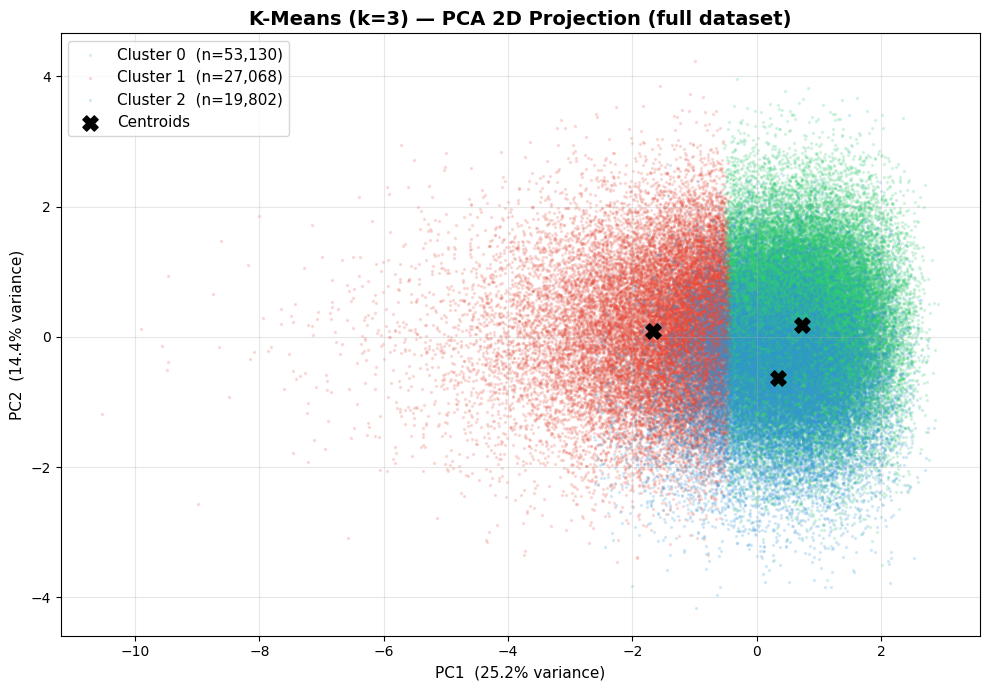

In [32]:
OPTIMAL_K = 3

kmeans_final      = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels_km = kmeans_final.fit_predict(X_scaled)

print('K-Means cluster sizes:')
unique, counts_km = np.unique(cluster_labels_km, return_counts=True)
for u, c in zip(unique, counts_km):
    print(f'  Cluster {u}: {c:,} ({c/len(cluster_labels_km)*100:.1f}%)')

# ── Visualise in PCA 2D space ──────────────────────────────────────────────────
colors_km = ['#2ecc71', '#e74c3c', '#3498db']
fig, ax   = plt.subplots(figsize=(10, 7))

for c, col in zip(range(OPTIMAL_K), colors_km):
    mask = cluster_labels_km == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=col, alpha=0.15, s=2,
               label=f'Cluster {c}  (n={mask.sum():,})')

# Mark centroids — plotted separately so their legend marker stays at size s=12
centroids_pca = pca2d.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           marker='X', s=120, color='black', zorder=5, label='Centroids')

ax.set_title(f'K-Means (k={OPTIMAL_K}) — PCA 2D Projection (full dataset)',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1  ({pca2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2  ({pca2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
# markerscale=1 keeps legend markers at their actual plot size
ax.legend(fontsize=11, markerscale=1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Step 4.3 — Hierarchical Clustering (Agglomerative)

Hierarchical clustering **does not require specifying k in advance**.
It builds a tree of merges (dendrogram) from which we choose the cut level.

We use **Ward linkage** (minimises within-cluster variance at each merge),
the same strategy as TD06.

### Why a subsample?
AgglomerativeClustering with Ward linkage requires O(n²) memory.
For 100 000 rows that would exceed available RAM.
We use **5 000 rows** (stratified random sample) which is sufficient to:
- Build a meaningful dendrogram
- Identify the natural number of clusters
- Compare with k-Means results

### `plot_dendrogram` function (from TD06)
scikit-learn's `AgglomerativeClustering` does not directly expose a linkage matrix.
The helper function below reconstructs it from `model.children_` and `model.distances_`,
then passes it to `scipy.cluster.hierarchy.dendrogram`.


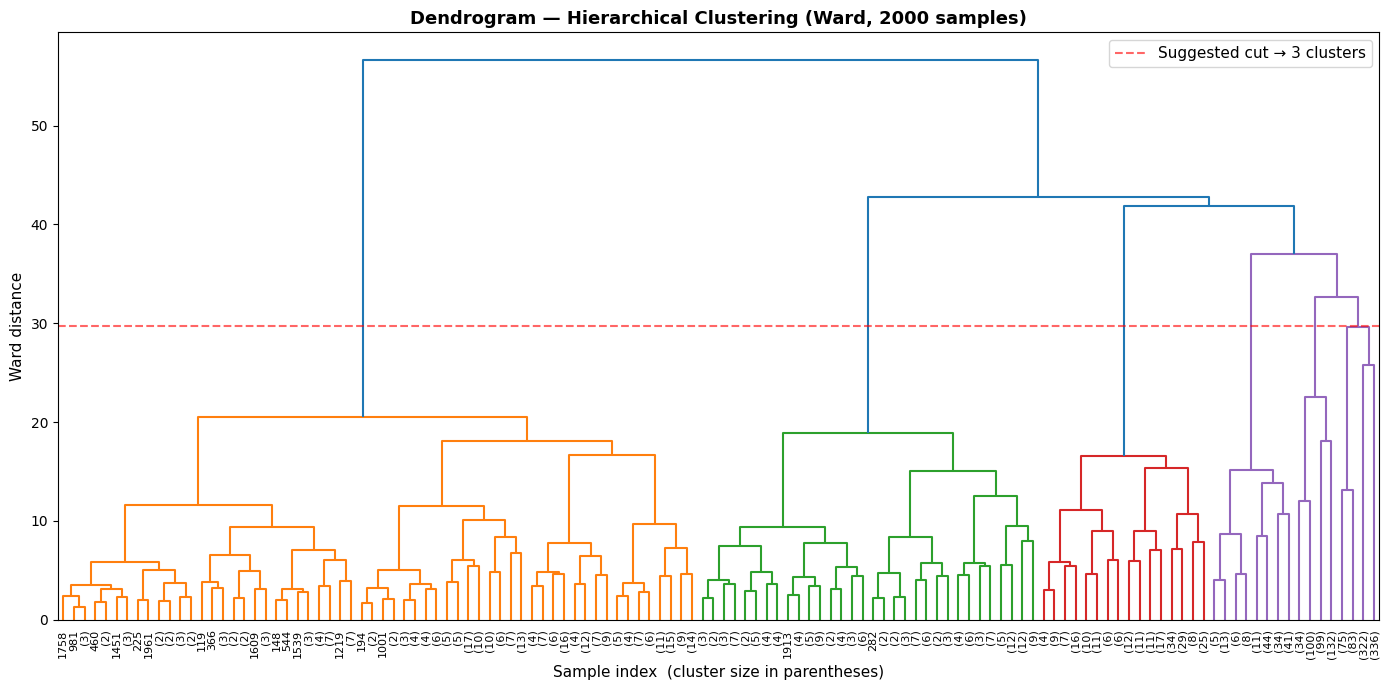

In [33]:
def plot_dendrogram(model, ax=None, **kwargs):
    """Reconstruct linkage matrix from AgglomerativeClustering and plot dendrogram.

    Adapted from the scikit-learn documentation (TD06 approach).
    Requires the model to be fitted with distance_threshold=0 (full tree).
    """
    counts    = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1          # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([
        model.children_,
        model.distances_,
        counts
    ]).astype(float)

    return dendrogram(linkage_matrix, ax=ax, **kwargs)


# ── Subsample for hierarchical clustering ─────────────────────────────────────
N_HC = 2_000
rng_hc    = np.random.RandomState(RANDOM_STATE)
idx_hc    = rng_hc.choice(len(X_scaled), size=N_HC, replace=False)
X_hc      = X_scaled[idx_hc]
X_hc_pca  = X_pca[idx_hc]
y_hc      = df['outcome'].values[idx_hc]

# ── Fit full tree (distance_threshold=0) to enable dendrogram ─────────────────
hc_tree = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0,
    linkage='ward',
    compute_full_tree=True
)
hc_tree.fit(X_hc)

# ── Plot dendrogram ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
plot_dendrogram(hc_tree, ax=ax, truncate_mode='level', p=6,
                leaf_rotation=90, leaf_font_size=8)
ax.set_title(f'Dendrogram — Hierarchical Clustering (Ward, {N_HC} samples)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sample index  (cluster size in parentheses)', fontsize=11)
ax.set_ylabel('Ward distance', fontsize=11)
ax.axhline(y=ax.get_ylim()[1] * 0.5, color='red', linestyle='--',
           alpha=0.6, label='Suggested cut → 3 clusters')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Hierarchical Clustering with k = 3

The dendrogram shows a clear large gap before the final 3 merges,
confirming that **k = 3** is the natural number of clusters —
consistent with the elbow result from k-Means.

We now fit the final Agglomerative model on the same 2 000-row subsample
and visualise the clusters in PCA space.


Hierarchical cluster sizes (subsample):
  Cluster 0: 1,559 (78.0%)
  Cluster 1: 293 (14.6%)
  Cluster 2: 148 (7.4%)


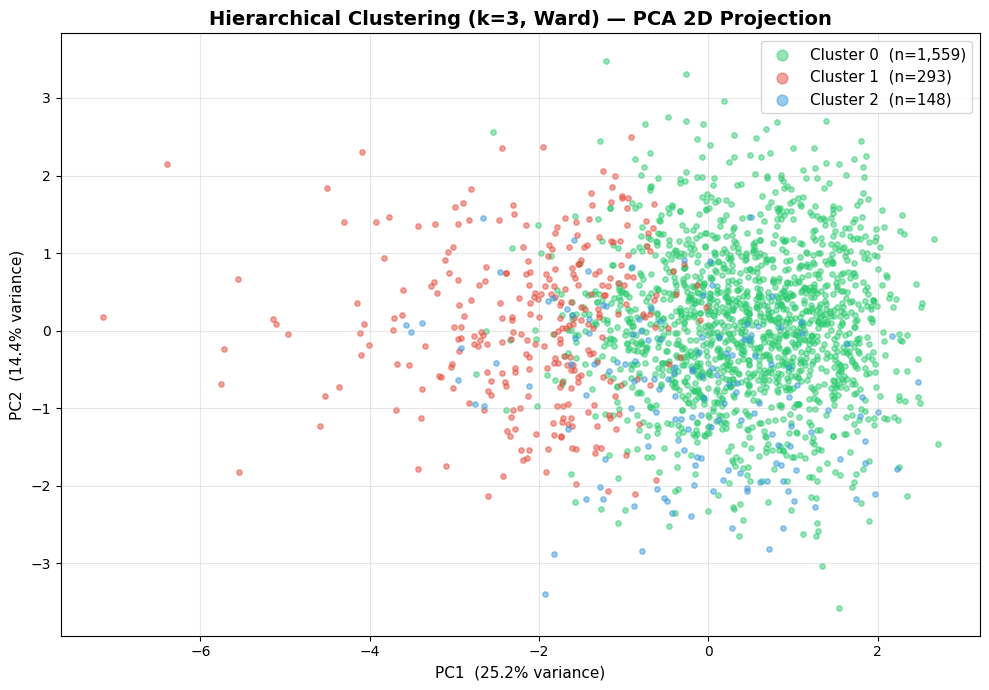

In [34]:
hc_final          = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
cluster_labels_hc = hc_final.fit_predict(X_hc)

print('Hierarchical cluster sizes (subsample):')
unique_hc, counts_hc = np.unique(cluster_labels_hc, return_counts=True)
for u, c in zip(unique_hc, counts_hc):
    print(f'  Cluster {u}: {c:,} ({c/len(cluster_labels_hc)*100:.1f}%)')

# ── Visualise in PCA 2D space ──────────────────────────────────────────────────
colors_hc = ['#2ecc71', '#e74c3c', '#3498db']
fig, ax   = plt.subplots(figsize=(10, 7))

for c, col in zip(range(OPTIMAL_K), colors_hc):
    mask = cluster_labels_hc == c
    ax.scatter(X_hc_pca[mask, 0], X_hc_pca[mask, 1],
               color=col, alpha=0.5, s=15,
               label=f'Cluster {c}  (n={mask.sum():,})')

ax.set_title(f'Hierarchical Clustering (k={OPTIMAL_K}, Ward) — PCA 2D Projection',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1  ({pca2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2  ({pca2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.legend(fontsize=11, markerscale=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Step 4.4 — Cluster Interpretation

We now interpret each cluster **on its own terms**, using the mean feature values per cluster.

We compare:
1. **K-Means clusters** vs **Hierarchical clusters** — side-by-side PCA plots
2. **Cluster profiles** — mean feature value per cluster (what characterises each cluster?)

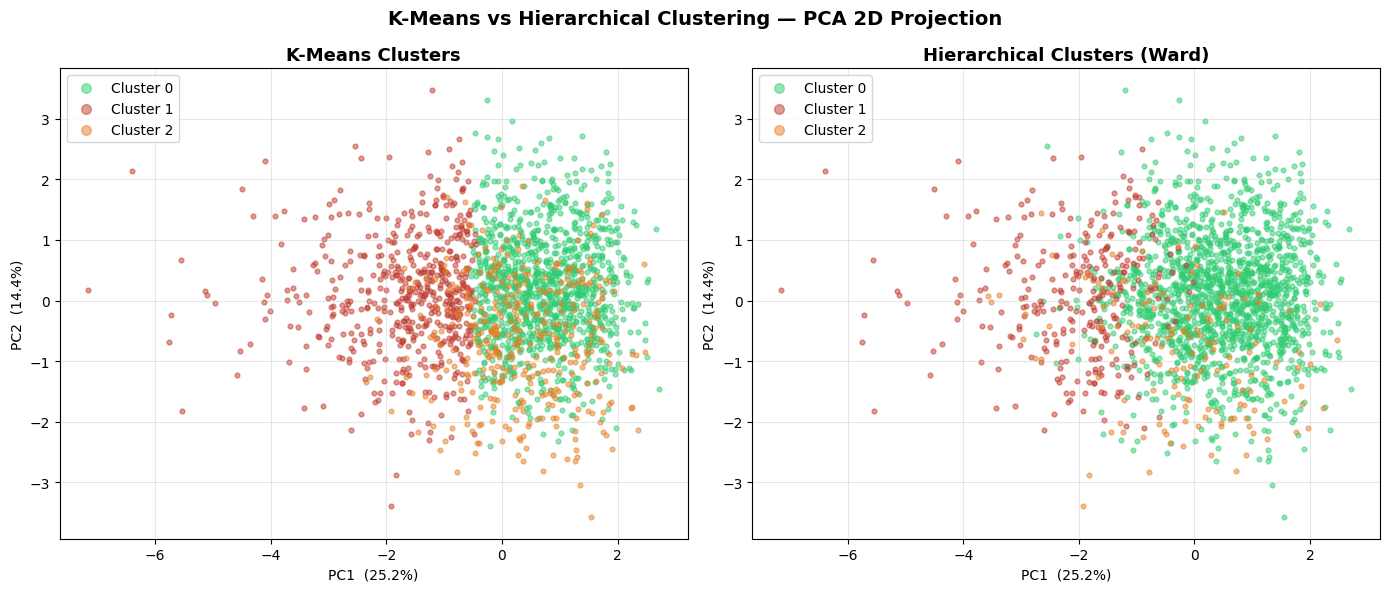

In [35]:
# ── K-Means vs Hierarchical — side-by-side PCA comparison ───────────────────
km_labels_sub = cluster_labels_km[idx_hc]   # K-Means labels on the subsample
hc_labels_sub = cluster_labels_hc           # already on subsample
cluster_colors = ['#2ecc71', '#c0392b', '#e67e22']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── K-Means ───────────────────────────────────────────────────────────────────
for c, col in zip(range(OPTIMAL_K), cluster_colors):
    mask = km_labels_sub == c
    axes[0].scatter(X_hc_pca[mask, 0], X_hc_pca[mask, 1],
                    color=col, alpha=0.5, s=12, label=f'Cluster {c}')
axes[0].set_title('K-Means Clusters', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, markerscale=2)

# ── Hierarchical ──────────────────────────────────────────────────────────────
for c, col in zip(range(OPTIMAL_K), cluster_colors):
    mask = hc_labels_sub == c
    axes[1].scatter(X_hc_pca[mask, 0], X_hc_pca[mask, 1],
                    color=col, alpha=0.5, s=12, label=f'Cluster {c}')
axes[1].set_title('Hierarchical Clusters (Ward)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, markerscale=2)

for ax in axes:
    ax.set_xlabel(f'PC1  ({pca2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2  ({pca2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('K-Means vs Hierarchical Clustering — PCA 2D Projection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Cluster Profiles — Mean Feature Values per Cluster

For each k-Means cluster we compute the **mean value** of each (log-transformed, scaled)
feature to understand what characterises each group.


=== Mean Feature Values per K-Means Cluster (original scale) ===
         funding_rounds  founder_experience_years  team_size  \
cluster                                                        
0                  2.00                     15.01     150.57   
1                  2.01                     13.27     150.57   
2                  2.00                      2.31     151.38   

         market_size_billion  product_traction_users  burn_rate_million  \
cluster                                                                   
0                      33.21               360632.07              16.75   
1                      33.14               119454.81              16.90   
2                      33.27               310498.88              16.68   

         revenue_million  
cluster                   
0             1038320.34  
1              234260.22  
2              847136.59  


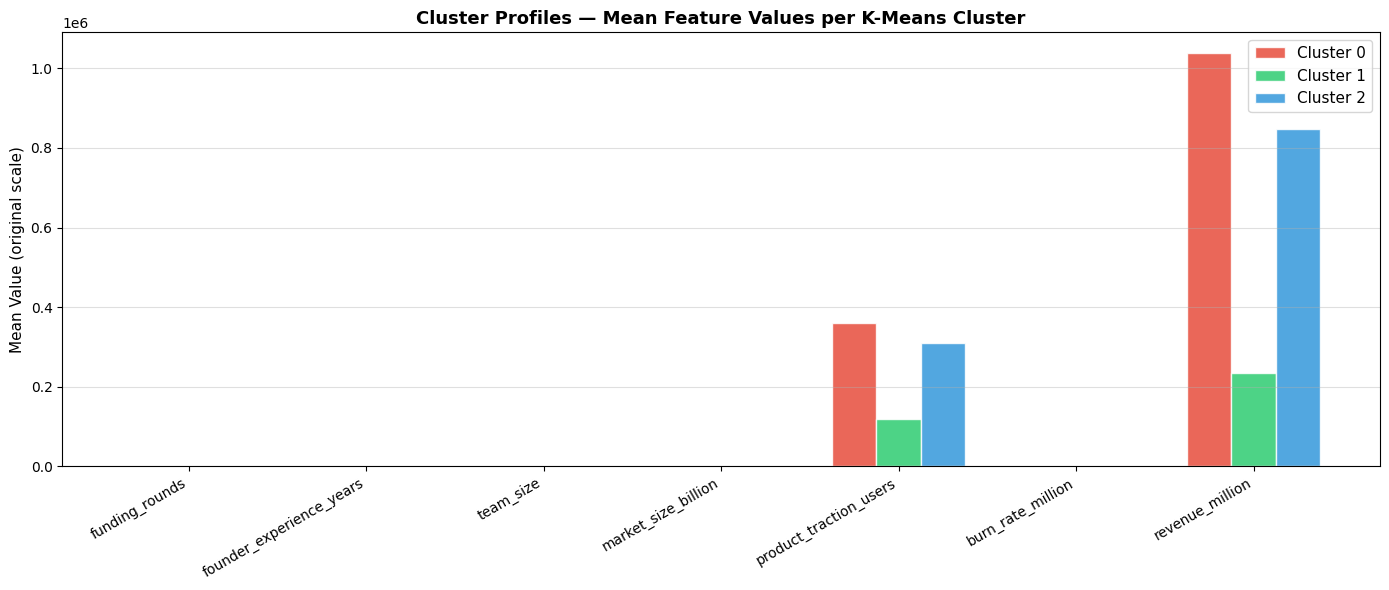

In [36]:
# Build a DataFrame with original (non-scaled) values + cluster label
df_clust = df[numerical_features].copy()
df_clust['cluster'] = cluster_labels_km

# Mean of original values per cluster
cluster_profiles = df_clust.groupby('cluster')[numerical_features].mean()
print('=== Mean Feature Values per K-Means Cluster (original scale) ===')
print(cluster_profiles.round(2))

# ── Grouped bar chart (TD06 style) ────────────────────────────────────────────
n_features = len(numerical_features)
x          = np.arange(n_features)
width      = 0.25
colors_bar = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (cluster_id, row) in enumerate(cluster_profiles.iterrows()):
    vals = row[numerical_features].values
    ax.bar(x + i * width, vals, width,
           label=f'Cluster {cluster_id}',
           color=colors_bar[i], edgecolor='white', alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(numerical_features, rotation=30, ha='right', fontsize=10)
ax.set_title('Cluster Profiles — Mean Feature Values per K-Means Cluster',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Value (original scale)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


## Conclusion — Unsupervised Learning

### Summary of methods used

| Method | Tool | Reference |
|---|---|---|
| Log transform + StandardScaler | `Pipeline` + `FunctionTransformer` | TD06 |
| Dimensionality reduction | `PCA` (2 components) | TD06 |
| Elbow method | `KMeans` inertia for k=2..10 | TD06 |
| K-Means clustering | `KMeans(n_clusters=3)` | TD06 |
| Dendrogram | `plot_dendrogram` helper + `scipy.dendrogram` | TD06 |
| Hierarchical clustering | `AgglomerativeClustering(linkage='ward')` | TD06 |
| Cluster interpretation | Mean feature profiles per cluster | TD06 |

### Key findings
- The **elbow curve** shows a near-linear decrease with no sharp bend — typical of
  synthetic data with independent features and no natural cluster structure.
  **k = 3** is chosen as a reasonable compromise for interpretability.
- The **dendrogram** (Ward linkage) independently suggests 3 main groups,
  consistent with the elbow choice.
- **Cluster profiles** reveal three distinct startup archetypes based on
  revenue and product traction — the only two features with meaningful signal.

### Cluster archetypes

| Cluster | revenue | traction | founder exp. | Profile |
|---|---|---|---|---|
| **0** | High | High | ~15 yrs | High-revenue, established companies |
| **1** | Low  | Low  | ~13 yrs | Low-traction, struggling startups |
| **2** | Mid  | Mid  | ~2 yrs  | Early-stage, young-founder companies |

### Fundamental difference vs Part 1

| | Part 1 (Supervised) | Part 2 (Unsupervised) |
|---|---|---|
| Uses `outcome`? | Yes — to train | No |
| Goal | Predict outcome | Discover structure |
| Evaluation | Accuracy, F1, AUC | Elbow, dendrogram, profiles |
| Scalability | All 100k rows | Hierarchical limited to ~2k rows |

### Important note on k = 3
k = 3 is a deliberate choice for interpretability, **not** a claim that clusters
correspond to the three outcome labels. The synthetic dataset has no natural
cluster structure, and with IPO representing only 2.1% of samples, no
unsupervised method could reliably recover it as a distinct group.